In [232]:
import io
import json
import math
import os
from datetime import datetime

import matplotlib.cm as cm
import matplotlib.pyplot as plt
import mlflow
import numpy as np
import torch
import torchvision
import torchvision.transforms as transforms
import torchvision.transforms.functional as TF
from PIL import Image
from torch import nn
from torch.nn import functional as F
import matplotlib.pyplot as plt
from visualizations import load_images_from_indices, visualize_attention, visualize_attention_on_images

In [233]:
from model import ViTForClassfication

In [234]:
def prepare_data(batch_size=4, num_workers=2, train_sample_size=None, test_sample_size=None):
    train_transform = transforms.Compose(
        [transforms.ToTensor(),
        transforms.Resize((32, 32)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomResizedCrop((32, 32), scale=(0.8, 1.0), ratio=(0.75, 1.3333333333333333), interpolation=2),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

    trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                            download=True, transform=train_transform)
    if train_sample_size is not None:
        # Randomly sample a subset of the training set
        indices = torch.randperm(len(trainset))[:train_sample_size]
        trainset = torch.utils.data.Subset(trainset, indices)



    trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size,
                                            shuffle=True, num_workers=num_workers)

    test_transform = transforms.Compose(
        [transforms.ToTensor(),
        transforms.Resize((32, 32)),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

    testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                        download=True, transform=test_transform)
    if test_sample_size is not None:
        # Randomly sample a subset of the test set
        indices = torch.randperm(len(testset))[:test_sample_size]
        testset = torch.utils.data.Subset(testset, indices)

    testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size,
                                            shuffle=False, num_workers=num_workers)

    classes = ('plane', 'car', 'bird', 'cat',
            'deer', 'dog', 'frog', 'horse', 'ship', 'truck')
    return trainloader, testloader, classes

In [235]:
trainloader, testloader, _ = prepare_data(batch_size=40)

/Users/valefeve/Projects/interpretable-transformers/venv/lib/python3.11/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


In [236]:
config = {
    "patch_size": 4,  # Input image size: 32x32 -> 8x8 patches
    "hidden_size": 48,
    "num_hidden_layers": 4,
    "num_attention_heads": 4,
    "intermediate_size": 4 * 48, # 4 * hidden_size
    "hidden_dropout_prob": 0.0,
    "attention_probs_dropout_prob": 0.0,
    "initializer_range": 0.02,
    "image_size": 32,
    "num_classes": 10, # num_classes of CIFAR10
    "num_channels": 3,
    "qkv_bias": True,
    "use_faster_attention": False,
}

In [237]:
model = ViTForClassfication(config).to('mps' if torch.backends.mps.is_available() else 'cpu')

In [238]:
model.load_state_dict(torch.load('vit_final_2026-04-15-17-36-04.pt', map_location='mps'))
model.eval()

ViTForClassfication(
  (embedding): Embeddings(
    (patch_embeddings): PatchEmbeddings(
      (projection): Conv2d(3, 48, kernel_size=(4, 4), stride=(4, 4))
    )
    (dropout): Dropout(p=0.0, inplace=False)
  )
  (encoder): Encoder(
    (blocks): ModuleList(
      (0-3): 4 x Block(
        (attention): MultiHeadAttention(
          (heads): ModuleList(
            (0-3): 4 x AttentionHead(
              (query): Linear(in_features=48, out_features=12, bias=True)
              (key): Linear(in_features=48, out_features=12, bias=True)
              (value): Linear(in_features=48, out_features=12, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (output_projection): Linear(in_features=48, out_features=48, bias=True)
          (output_dropout): Dropout(p=0.0, inplace=False)
        )
        (layernorm_1): LayerNorm((48,), eps=1e-05, elementwise_affine=True)
        (mlp): MLP(
          (dense_1): Linear(in_features=48, out_features=1

In [239]:
images = load_images_from_indices(testloader.dataset, [0, 1, 2, 3, 4, 5])
input_images = images.to('mps')
logits, attention_maps = model(images, output_attentions=True)

In [240]:
def diversity_loss(attn):
    """
    attn: (batch, n_heads, n_tokens) — distribuciones de atención ya softmax
    
    Para cada cabeza i, calcula qué tan similar es a cada otra cabeza j
    usando el producto punto (análogo a tr(x·T) del paper).
    
    Luego pasa por softmax para obtener una "distribución de similitud"
    y penaliza cuando alguna cabeza j es muy similar a i.
    
    El loss total es la suma sobre todas las cabezas.
    """
    batch, n_heads, n_tokens = attn.shape
    
    # Producto punto entre todos los pares de cabezas
    # attn: (batch, n_heads, n_tokens)
    # similarity: (batch, n_heads, n_heads)
    similarity = torch.bmm(attn, attn.transpose(1, 2))  # x_i · x_j
    
    # Enmascarar la diagonal (no comparar cabeza consigo misma)
    mask = ~torch.eye(n_heads, dtype=torch.bool).unsqueeze(0)  # (1, n_heads, n_heads)
    
    # Para cada cabeza i, softmax sobre las similitudes con las demás
    # Esto es: exp(x_i · x_j) / sum_k≠i exp(x_i · x_k)
    sim_masked = similarity.masked_fill(~mask, float('-inf'))
    sim_softmax = F.softmax(sim_masked, dim=-1)  # (batch, n_heads, n_heads)
    
    # Si todas las cabezas fueran igualmente (dis)similares,
    # esta distribución sería uniforme → entropía máxima → bien
    # Si una cabeza j domina → entropía baja → mal → hay redundancia
    
    # Entropía de la distribución de similitud para cada cabeza
    # H(sim_i) = -sum_j p_ij * log(p_ij)
    log_sim = sim_softmax.clamp(min=1e-10).log()
    entropy_per_head = -(sim_softmax * log_sim).sum(dim=-1)  # (batch, n_heads)
    
    # Queremos MAXIMIZAR entropía → MINIMIZAR -entropía
    # Loss = -entropía promedio (sobre batch y cabezas)
    loss = -entropy_per_head.mean()
    
    return loss, {
        'similarity_matrix': similarity.mean(dim=0),       # (n_heads, n_heads) promedio
        'sim_softmax': sim_softmax.mean(dim=0),             # distribución de similitud promedio
        'entropy_per_head': entropy_per_head.mean(dim=0),   # entropía promedio por cabeza
        'loss': loss.item(),
    }

In [241]:
attention_maps[-1].shape

torch.Size([6, 4, 65, 65])

In [242]:
diversity_loss(attention_maps[-1][:, :, 0, 1:].to('cpu'))

(tensor(-1.0986, grad_fn=<NegBackward0>),
 {'similarity_matrix': tensor([[0.0152, 0.0151, 0.0152, 0.0151],
          [0.0151, 0.0151, 0.0151, 0.0151],
          [0.0152, 0.0151, 0.0152, 0.0151],
          [0.0151, 0.0151, 0.0151, 0.0151]], grad_fn=<MeanBackward1>),
  'sim_softmax': tensor([[0.0000, 0.3333, 0.3333, 0.3333],
          [0.3333, 0.0000, 0.3333, 0.3333],
          [0.3333, 0.3333, 0.0000, 0.3333],
          [0.3333, 0.3333, 0.3333, 0.0000]], grad_fn=<MeanBackward1>),
  'entropy_per_head': tensor([1.0986, 1.0986, 1.0986, 1.0986], grad_fn=<MeanBackward1>),
  'loss': -1.0986123085021973})

In [264]:
attn = attention_maps[-1][:, :, 0, 1:].to('cpu')
attn.shape

torch.Size([6, 4, 64])

In [265]:
# Describe attn
print(f"Shape of attn: {attn.shape}")  # (batch, n_heads, n_tokens)
print(f"Max value in attn: {attn.max().item():.4f}")
print(f"Min value in attn: {attn.min().item():.4f}")
print(f"Mean value in attn: {attn.mean().item():.4f}")

Shape of attn: torch.Size([6, 4, 64])
Max value in attn: 0.0163
Min value in attn: 0.0144
Mean value in attn: 0.0154


In [266]:
batch, n_heads, n_tokens = attn.shape


In [267]:
attn[0][1].sum()

tensor(0.9846, grad_fn=<SumBackward0>)

In [268]:
attn[0][0].sum()

tensor(0.9846, grad_fn=<SumBackward0>)

In [269]:
print(attn[0][0])
print(attn[0][1])

tensor([0.0151, 0.0152, 0.0152, 0.0153, 0.0152, 0.0153, 0.0153, 0.0152, 0.0152,
        0.0151, 0.0149, 0.0150, 0.0152, 0.0157, 0.0154, 0.0152, 0.0152, 0.0150,
        0.0157, 0.0154, 0.0153, 0.0154, 0.0155, 0.0152, 0.0153, 0.0153, 0.0150,
        0.0157, 0.0151, 0.0153, 0.0154, 0.0154, 0.0155, 0.0152, 0.0152, 0.0150,
        0.0154, 0.0155, 0.0151, 0.0152, 0.0157, 0.0151, 0.0155, 0.0156, 0.0161,
        0.0154, 0.0156, 0.0157, 0.0155, 0.0154, 0.0155, 0.0155, 0.0157, 0.0156,
        0.0159, 0.0156, 0.0156, 0.0154, 0.0156, 0.0154, 0.0157, 0.0156, 0.0155,
        0.0155], grad_fn=<SelectBackward0>)
tensor([0.0151, 0.0154, 0.0151, 0.0152, 0.0152, 0.0157, 0.0155, 0.0154, 0.0157,
        0.0153, 0.0156, 0.0155, 0.0155, 0.0150, 0.0157, 0.0156, 0.0146, 0.0154,
        0.0148, 0.0151, 0.0156, 0.0153, 0.0152, 0.0157, 0.0153, 0.0155, 0.0152,
        0.0150, 0.0150, 0.0150, 0.0155, 0.0154, 0.0150, 0.0151, 0.0153, 0.0151,
        0.0156, 0.0160, 0.0155, 0.0153, 0.0153, 0.0146, 0.0152, 0.0157, 0.01

In [270]:
attn.mean(dim=-1)

tensor([[0.0154, 0.0154, 0.0154, 0.0154],
        [0.0154, 0.0154, 0.0154, 0.0154],
        [0.0154, 0.0154, 0.0154, 0.0154],
        [0.0154, 0.0154, 0.0154, 0.0154],
        [0.0154, 0.0154, 0.0154, 0.0154],
        [0.0154, 0.0154, 0.0154, 0.0154]], grad_fn=<MeanBackward1>)

In [271]:
u = attn - attn.mean(dim=-1, keepdim=True)
print(u)
print(u.mean())
print(u.min())
print(u.max())  

tensor([[[-2.5877e-04, -2.2601e-04, -2.2558e-04,  ...,  2.3635e-04,
           1.2255e-04,  1.5079e-04],
         [-2.4018e-04,  5.8312e-05, -2.4499e-04,  ...,  5.1958e-05,
          -2.0540e-04,  1.0613e-04],
         [ 3.5093e-05,  2.6687e-04,  2.4613e-04,  ..., -3.2607e-04,
           2.4834e-05, -3.5082e-04],
         [ 4.4817e-04,  4.3183e-04,  3.3336e-04,  ..., -2.1235e-04,
          -7.4265e-04, -2.2512e-04]],

        [[ 1.5018e-04,  1.8857e-04,  1.6890e-04,  ..., -1.1180e-04,
          -7.7110e-04, -1.3135e-05],
         [-3.0952e-04, -1.6856e-04, -2.5352e-04,  ..., -2.8679e-04,
          -9.9235e-04, -2.0777e-04],
         [ 2.3714e-04,  3.5805e-04,  3.6441e-04,  ..., -3.8469e-04,
          -2.4054e-04,  3.6234e-04],
         [-3.6760e-04, -3.3898e-04, -3.8666e-04,  ...,  3.7702e-04,
          -6.1275e-04, -2.2292e-04]],

        [[ 1.3179e-04,  1.5153e-04,  1.2627e-04,  ..., -1.7656e-04,
          -2.9903e-04, -2.5202e-04],
         [-4.5119e-04, -2.9478e-04, -3.7458e-04,  .

In [272]:
attn = F.relu(attn - attn.mean(dim=-1, keepdim=True))
#Normalizar para que siga siendo una distribución de probabilidad usando F.normalize
attn = F.normalize(attn, p=5, dim=-1)
print(attn)

tensor([[[0.0000, 0.0000, 0.0000,  ..., 0.3308, 0.1715, 0.2110],
         [0.0000, 0.0871, 0.0000,  ..., 0.0776, 0.0000, 0.1586],
         [0.0580, 0.4412, 0.4069,  ..., 0.0000, 0.0411, 0.0000],
         [0.5332, 0.5138, 0.3966,  ..., 0.0000, 0.0000, 0.0000]],

        [[0.3115, 0.3911, 0.3503,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.3283, 0.4957, 0.5045,  ..., 0.0000, 0.0000, 0.5016],
         [0.0000, 0.0000, 0.0000,  ..., 0.3456, 0.0000, 0.0000]],

        [[0.2501, 0.2875, 0.2396,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000,  ..., 0.1356, 0.0282, 0.2753],
         [0.0000, 0.4732, 0.5035,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000,  ..., 0.5630, 0.4357, 0.5439]],

        [[0.1472, 0.4310, 0.1733,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0160, 0.0000,  ..., 0.0000, 0.0000, 0.3248],
         [0.0809, 0.2235, 0.4384,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0

In [273]:

similarity = torch.bmm(attn, attn.transpose(1, 2))  # x_i · x_j
similarity

tensor([[[3.7066, 1.5328, 1.1600, 0.1647],
         [1.5328, 4.2848, 1.2778, 2.4174],
         [1.1600, 1.2778, 4.7063, 2.6154],
         [0.1647, 2.4174, 2.6154, 6.4794]],

        [[5.7866, 1.3772, 3.9974, 0.1267],
         [1.3772, 3.9717, 0.5644, 2.9810],
         [3.9974, 0.5644, 6.4868, 0.6659],
         [0.1267, 2.9810, 0.6659, 5.4593]],

        [[3.8951, 1.1601, 2.8477, 0.6932],
         [1.1601, 4.5660, 0.5598, 3.8038],
         [2.8477, 0.5598, 5.4337, 0.4448],
         [0.6932, 3.8038, 0.4448, 6.0133]],

        [[5.7615, 0.3701, 3.5839, 0.0128],
         [0.3701, 3.7135, 0.4815, 3.0480],
         [3.5839, 0.4815, 4.4501, 0.1797],
         [0.0128, 3.0480, 0.1797, 4.8678]],

        [[4.5873, 0.9574, 3.0140, 1.1822],
         [0.9574, 4.3631, 0.5294, 3.5268],
         [3.0140, 0.5294, 4.1243, 0.4032],
         [1.1822, 3.5268, 0.4032, 5.3878]],

        [[2.4129, 0.2696, 0.6205, 0.1891],
         [0.2696, 3.7452, 0.6961, 0.9951],
         [0.6205, 0.6961, 3.9597, 1.8689],
 

In [274]:

# Enmascarar la diagonal (no comparar cabeza consigo misma)
mask = ~torch.eye(n_heads, dtype=torch.bool).unsqueeze(0)  # (1, n_heads, n_heads)


In [275]:

# Para cada cabeza i, softmax sobre las similitudes con las demás
# Esto es: exp(x_i · x_j) / sum_k≠i exp(x_i · x_k)
sim_masked = similarity.masked_fill(~mask, 0)
sim_masked

tensor([[[0.0000, 1.5328, 1.1600, 0.1647],
         [1.5328, 0.0000, 1.2778, 2.4174],
         [1.1600, 1.2778, 0.0000, 2.6154],
         [0.1647, 2.4174, 2.6154, 0.0000]],

        [[0.0000, 1.3772, 3.9974, 0.1267],
         [1.3772, 0.0000, 0.5644, 2.9810],
         [3.9974, 0.5644, 0.0000, 0.6659],
         [0.1267, 2.9810, 0.6659, 0.0000]],

        [[0.0000, 1.1601, 2.8477, 0.6932],
         [1.1601, 0.0000, 0.5598, 3.8038],
         [2.8477, 0.5598, 0.0000, 0.4448],
         [0.6932, 3.8038, 0.4448, 0.0000]],

        [[0.0000, 0.3701, 3.5839, 0.0128],
         [0.3701, 0.0000, 0.4815, 3.0480],
         [3.5839, 0.4815, 0.0000, 0.1797],
         [0.0128, 3.0480, 0.1797, 0.0000]],

        [[0.0000, 0.9574, 3.0140, 1.1822],
         [0.9574, 0.0000, 0.5294, 3.5268],
         [3.0140, 0.5294, 0.0000, 0.4032],
         [1.1822, 3.5268, 0.4032, 0.0000]],

        [[0.0000, 0.2696, 0.6205, 0.1891],
         [0.2696, 0.0000, 0.6961, 0.9951],
         [0.6205, 0.6961, 0.0000, 1.8689],
 

In [276]:
sim_masked.shape

torch.Size([6, 4, 4])

In [277]:

sim_softmax = F.softmax(sim_masked, dim=-1)  # (batch, n_heads, n_heads)
sim_softmax.shape
sim_softmax

tensor([[[0.1000, 0.4631, 0.3190, 0.1179],
         [0.2266, 0.0489, 0.1756, 0.5489],
         [0.1487, 0.1673, 0.0466, 0.6374],
         [0.0436, 0.4144, 0.5051, 0.0369]],

        [[0.0165, 0.0655, 0.8993, 0.0187],
         [0.1500, 0.0378, 0.0665, 0.7457],
         [0.9205, 0.0297, 0.0169, 0.0329],
         [0.0477, 0.8284, 0.0818, 0.0420]],

        [[0.0427, 0.1361, 0.7359, 0.0853],
         [0.0628, 0.0197, 0.0344, 0.8831],
         [0.8000, 0.0812, 0.0464, 0.0724],
         [0.0405, 0.9077, 0.0316, 0.0202]],

        [[0.0253, 0.0367, 0.9123, 0.0257],
         [0.0576, 0.0398, 0.0644, 0.8382],
         [0.9042, 0.0406, 0.0251, 0.0301],
         [0.0417, 0.8678, 0.0493, 0.0412]],

        [[0.0367, 0.0956, 0.7479, 0.1198],
         [0.0663, 0.0254, 0.0432, 0.8651],
         [0.8292, 0.0691, 0.0407, 0.0609],
         [0.0820, 0.8552, 0.0376, 0.0251]],

        [[0.1860, 0.2435, 0.3459, 0.2247],
         [0.1865, 0.1424, 0.2857, 0.3853],
         [0.1639, 0.1768, 0.0881, 0.5712],
 

In [278]:

# Si todas las cabezas fueran igualmente (dis)similares,
# esta distribución sería uniforme → entropía máxima → bien
# Si una cabeza j domina → entropía baja → mal → hay redundancia

# Entropía de la distribución de similitud para cada cabeza
# H(sim_i) = -sum_j p_ij * log(p_ij)
log_sim = sim_softmax.clamp(min=1e-10).log()
entropy_per_head = -(sim_softmax * log_sim).sum(dim=-1)  # (batch, n_heads)
entropy_per_head

tensor([[1.2033, 1.1188, 1.0125, 0.9684],
        [0.4162, 0.8076, 0.3621, 0.6391],
        [0.8417, 0.4769, 0.7148, 0.4056],
        [0.3921, 0.6172, 0.4191, 0.5353],
        [0.8172, 0.5343, 0.6408, 0.5549],
        [1.3595, 1.3162, 1.1367, 1.1138]], grad_fn=<NegBackward0>)

In [279]:

# Queremos MAXIMIZAR entropía → MINIMIZAR -entropía
# Loss = -entropía promedio (sobre batch y cabezas)
loss = entropy_per_head.mean()


In [280]:
loss

tensor(0.7668, grad_fn=<MeanBackward0>)

In [260]:
def diversity_loss_gram(attn):
    """
    attn: (batch, n_heads, n_tokens) — distribuciones de atención ya softmax

    Mide diversidad entre cabezas usando el determinante de la matriz de Gram.

    El determinante captura el "volumen" que abarcan los vectores de atención
    como conjunto:
      - Cabezas diversas → apuntan en direcciones distintas → volumen grande → det grande
      - Cabezas redundantes → casi colineales → det cerca de cero

    Normalización coseno antes del dot product elimina el problema de escala
    que colapsaba el pipeline anterior (softmax+entropía sobre valores tiny).
    """
    batch, n_heads, n_tokens = attn.shape

    # Normalizar a norma unitaria: convierte dot product en similitud coseno
    # Ahora los valores están acotados en [-1, 1] independientemente de la escala
    attn_norm = F.normalize(attn, p=2, dim=-1)  # (batch, n_heads, n_tokens)

    # Matriz de Gram: similitud coseno entre todos los pares de cabezas
    # G[i,j] = cos(head_i, head_j) ∈ [-1, 1]
    G = torch.bmm(attn_norm, attn_norm.transpose(1, 2))  # (batch, n_heads, n_heads)

    # log-determinante: más estable numéricamente que det directo
    # slogdet devuelve (signo, log|det|) — usamos solo el log
    # Queremos MAXIMIZAR det(G) → MINIMIZAR -logdet
    sign, logdet = torch.linalg.slogdet(G)

    loss = -logdet.mean()

    # Similitud coseno promedio off-diagonal: interpretable directamente
    mask = ~torch.eye(n_heads, dtype=torch.bool, device=attn.device)
    mean_cos_sim = G[:, mask].mean().item()

    return loss, {
        'gram_matrix': G.mean(dim=0),          # (n_heads, n_heads) promedio sobre batch
        'logdet_per_sample': logdet,            # (batch,)
        'mean_logdet': logdet.mean().item(),
        'mean_cos_sim_offdiag': mean_cos_sim,  # 0 = ortogonales (máx diversidad), 1 = idénticas
        'loss': loss.item(),
    }

In [261]:
# Extraer atención del CLS token hacia los patches (última capa)
attn_raw = attention_maps[-1][:, :, 0, 1:].to('cpu')

loss_gram, info_gram = diversity_loss_gram(attn_raw)

print(f"Loss (Gram):          {info_gram['loss']:.4f}")
print(f"Mean log-det:         {info_gram['mean_logdet']:.4f}")
print(f"Mean cosine sim (off-diag): {info_gram['mean_cos_sim_offdiag']:.4f}")
print()
print("Gram matrix (promedio sobre batch):")
print(info_gram['gram_matrix'])

Loss (Gram):          24.0526
Mean log-det:         -24.0526
Mean cosine sim (off-diag): 0.9996

Gram matrix (promedio sobre batch):
tensor([[1.0000, 0.9998, 0.9998, 0.9995],
        [0.9998, 1.0000, 0.9995, 0.9998],
        [0.9998, 0.9995, 1.0000, 0.9993],
        [0.9995, 0.9998, 0.9993, 1.0000]], grad_fn=<MeanBackward1>)


In [262]:
# Comparar diversity_loss_gram por capa
# Permite ver si la redundancia está distribuida o concentrada en capas específicas
print(f"{'Capa':<8} {'logdet':>10} {'cos_sim':>10} {'loss':>10}")
print("-" * 42)
for i, attn_layer in enumerate(attention_maps):
    attn = attn_layer[:, :, 0, 1:].to('cpu')
    _, info = diversity_loss_gram(attn)
    print(f"Layer {i:<3} {info['mean_logdet']:>10.4f} {info['mean_cos_sim_offdiag']:>10.4f} {info['loss']:>10.4f}")

Capa         logdet    cos_sim       loss
------------------------------------------
Layer 0     -24.2385     0.9997    24.2385
Layer 1     -25.3577     0.9998    25.3577
Layer 2     -25.0833     0.9998    25.0833
Layer 3     -24.0526     0.9996    24.0526


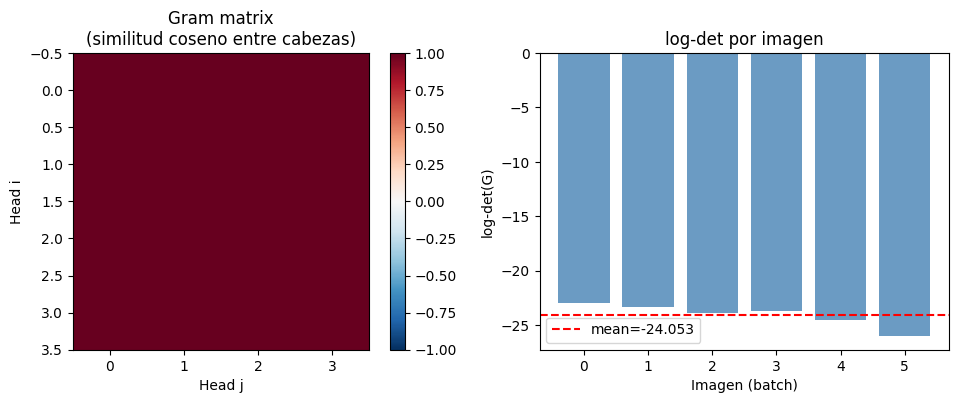

In [263]:
# Visualizar la Gram matrix de la última capa
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

G = info_gram['gram_matrix'].detach().numpy()

im0 = axes[0].imshow(G, cmap='RdBu_r', vmin=-1, vmax=1)
axes[0].set_title('Gram matrix\n(similitud coseno entre cabezas)')
axes[0].set_xlabel('Head j')
axes[0].set_ylabel('Head i')
plt.colorbar(im0, ax=axes[0])

# Heatmap de logdet por sample para ver variabilidad
logdets = info_gram['logdet_per_sample'].detach().numpy()
axes[1].bar(range(len(logdets)), logdets, color='steelblue', alpha=0.8)
axes[1].axhline(y=logdets.mean(), color='red', linestyle='--', label=f'mean={logdets.mean():.3f}')
axes[1].set_title('log-det por imagen')
axes[1].set_xlabel('Imagen (batch)')
axes[1].set_ylabel('log-det(G)')
axes[1].legend()

plt.tight_layout()
plt.show()